In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy as sp
from scipy import io
import skimage
import skimage.morphology
import scipy.ndimage as ndimage
from skimage import measure

In [7]:
def rgbify(image, rgb_bands = (54, 32, 18)):
    hsi_rgb = image[:,:,rgb_bands]
    hsi_rgb = hsi_rgb/hsi_rgb.max() # normalisation des valeurs dans [0,1] pour l'affichage

    pmin,pmax = np.percentile(hsi_rgb,(1,95),axis=(0,1))
    pminc,pmaxc = np.percentile(hsi_rgb,(1,90),axis=(0,1))
    hsi_rgb_pimped = hsi_rgb.copy()
    for i in range(pmin.size):
        hsi_rgb_pimped[:,:,i] = (hsi_rgb[:,:,i]-pmin[i])/(pmax[i]-pmin[i])
    hsi_rgb_pimped[hsi_rgb_pimped<0] = 0
    hsi_rgb_pimped[hsi_rgb_pimped>1] = 1
           
    return (hsi_rgb, hsi_rgb_pimped)

# Preprocessing

## Loading Data

In [8]:
data = sp.io.loadmat('data/2013_DFC_contest.mat')

In [9]:
lidar = data['lidar']

In [10]:
hsi_raw = data['hyper']
print("L'image hyperspectrale est composée de %d lignes, %d colonnes et %d bandes "%(hsi_raw.shape)
      +"au format %s"%hsi_raw.dtype)

L'image hyperspectrale est composée de 349 lignes, 1905 colonnes et 144 bandes au format uint16


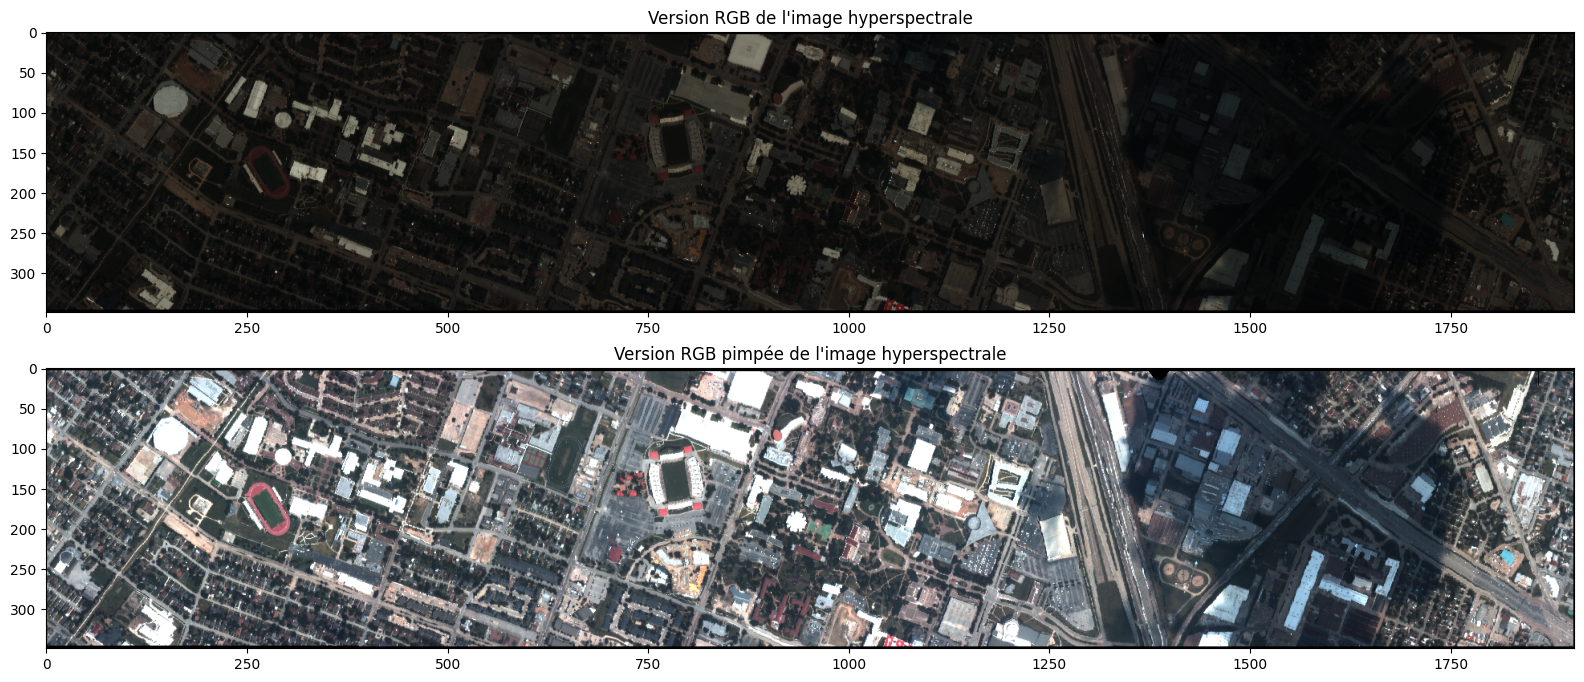

In [11]:
hsi_rgb, hsi_rgb_pimped = rgbify(hsi_raw)
plt.figure(figsize=(20,8))
plt.subplot(211)
plt.title("Version RGB de l'image hyperspectrale")
plt.imshow(hsi_rgb)
plt.subplot(212)
plt.title("Version RGB pimpée de l'image hyperspectrale")
plt.imshow(hsi_rgb_pimped)
plt.show()

In [12]:
groundtruth = np.load('groundtruth/groundtruth.npy')
groundtruth_info = np.load('groundtruth/groundtruth_info.npy',allow_pickle=True)
groundtruth_rgb = plt.imread('groundtruth/groundtruth.png')

In [13]:
np.unique(groundtruth)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15])

## Nuage

### Détéction du nuage

/var/folders/_5/q5djzf3j101ch1t5bw1hjjnw000103/T/ipykernel_42755/1122868549.py:13: RuntimeWarning: invalid value encountered in divide
  ratio = np.divide(band1, band2)


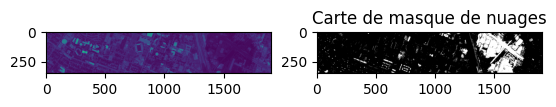

In [14]:
# Sélectionner les longueurs d'onde pour le calcul du ratio spectral
wl1 = 440  # Longueur d'onde pour la bande bleue
wl2 = 870  # Longueur d'onde pour la bande infrarouge

# Calculer les longueurs d'onde de l'image hyperspectrale
wavelengths = np.linspace(380, 1050, hsi_raw.shape[2])

# Extraire les bandes de longueurs d'onde sélectionnées
band1 = hsi_raw[:, :, np.argmin(abs(wavelengths - wl1))]
band2 = hsi_raw[:, :, np.argmin(abs(wavelengths - wl2))]

# Calculer le ratio spectral
ratio = np.divide(band1, band2)

# Seuiller le ratio spectral pour détecter les nuages (threshold optimal)
threshold = 1.16
cloud_mask = np.where(ratio > threshold, 1, 0)

cloud_mask_cp = cloud_mask.copy()
# Visualisation des résultats
plt.subplot(1, 2, 1)
plt.imshow(hsi_raw[:, :, 54])

plt.subplot(1, 2, 2)
plt.imshow(cloud_mask, cmap='gray')
plt.title('Carte de masque de nuages')

plt.show()

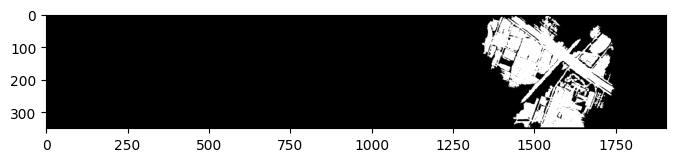

In [15]:
# Identifier les différentes régions connectées dans le masque de nuages
labelled_mask = measure.label(cloud_mask)

# Récupérer les propriétés de chaque région
props = measure.regionprops(labelled_mask)

# Trouver l'indice de la région la plus grande
max_area = 0
max_index = 0
for i, region in enumerate(props):
    if region.area > max_area:
        max_area = region.area
        max_index = i

# Créer un masque pour la région la plus grande
largest_region_mask = np.zeros_like(cloud_mask)
largest_region_mask[labelled_mask == max_index + 1] = 1

# Visualisation des résultats
fig, ax = plt.subplots(figsize=(8,8))
ax.imshow(largest_region_mask, cmap='gray')
#ax.title('Carte de masque de nuages avec la plus grande région')

plt.show()

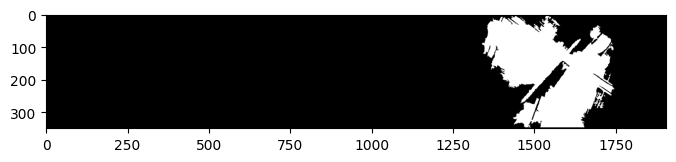

In [16]:
# Remplir les trous dans la région la plus grande
filled_mask = ndimage.binary_fill_holes(largest_region_mask)
fig, ax = plt.subplots(figsize=(8,8))
ax.imshow(filled_mask, cmap='gray')

In [17]:
# Ensure the mask has same size as hsi_raw data (but its depth)
assert filled_mask.shape == hsi_raw.shape[:-1]

In [18]:
filled_mask.shape

(349, 1905)

### Restriction du nuage

In [32]:
hsi_cloud_reduction = hsi_raw.copy()
cloud_pos = np.where(filled_mask)
no_cloud_pos = np.where(~filled_mask)
for i in range(144):
    pic = hsi_cloud_reduction[:,:,i]
    
    cloud_img = pic[cloud_pos]
    nocloud_img = pic[no_cloud_pos]
    pic[cloud_pos] = skimage.exposure.match_histograms(cloud_img, nocloud_img)
    #pic[:] = skimage.exposure.equalize_hist(pic[:])

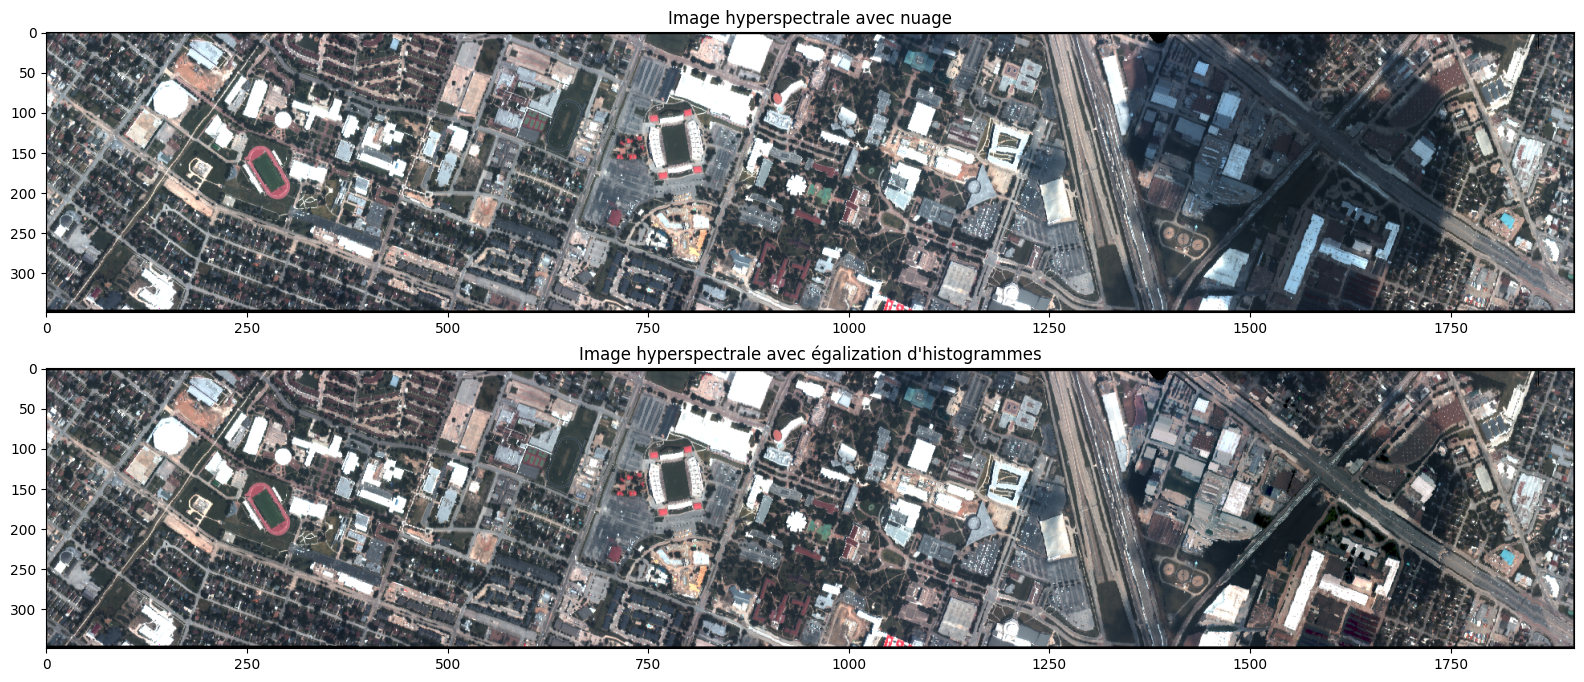

In [33]:
_, hsi_rgb_nocloud = rgbify(hsi_cloud_reduction)

plt.figure(figsize=(20,8))
plt.subplot(211)
plt.title("Image hyperspectrale avec nuage")
plt.imshow(hsi_rgb_pimped)
plt.subplot(212)
plt.title("Image hyperspectrale avec égalization d'histogrammes")
plt.imshow(hsi_rgb_nocloud)
plt.show()

## Preparing data for training

In [16]:
counter = {}
for ii in range(16):
    pixels = (groundtruth==ii).sum()
    print("Classe %d : %s (%d pixels au total)"%(ii,groundtruth_info[ii-1]['class_name'] if ii else "Unknown", pixels))
    counter[ii] = pixels
    
del counter[0]
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", [groundtruth_info[cls]['class_color']/255. for cls in range(15)])

Classe 0 : Unknown (662013 pixels au total)
Classe 1 : grass_healthy (198 pixels au total)
Classe 2 : grass_stressed (190 pixels au total)
Classe 3 : grass_synthetic (192 pixels au total)
Classe 4 : tree (188 pixels au total)
Classe 5 : soil (186 pixels au total)
Classe 6 : water (182 pixels au total)
Classe 7 : residential (196 pixels au total)
Classe 8 : commercial (191 pixels au total)
Classe 9 : road (193 pixels au total)
Classe 10 : highway (191 pixels au total)
Classe 11 : railway (181 pixels au total)
Classe 12 : parking_lot1 (192 pixels au total)
Classe 13 : parking_lot2 (184 pixels au total)
Classe 14 : tennis_court (181 pixels au total)
Classe 15 : running_track (187 pixels au total)


In [17]:
positions = np.where(groundtruth != 0)

In [18]:
labels = groundtruth[positions]

In [19]:
groundtruth_hsi = hsi_raw[positions[0], positions[1], :]

In [20]:
groundtruth_cloudmask = filled_mask[positions]

In [21]:
no_pixels, no_bands = groundtruth_hsi.shape
no_pixels, no_bands

(2832, 144)

In [22]:
# Build values set
whole_set = np.zeros((no_pixels, no_bands + 2))
whole_set[:, :144] = groundtruth_hsi
whole_set[:, 144] = lidar[positions]
whole_set[:, 145] = groundtruth_cloudmask
#whole_set[:, 145] = positions[0]
#whole_set[:, 146] = positions[1]

In [23]:
whole_set.shape

(2832, 146)

In [24]:
# Check whole_set has same size as labels
assert len(labels) == len(whole_set)

# Classification

In [25]:
# TODO: Trier ceux qu'on utilise vraiment
import sklearn.svm
import sklearn.tree
import sklearn.ensemble
import sklearn.neighbors
import sklearn.gaussian_process
import sklearn.discriminant_analysis
import sklearn.cluster

In [89]:
#classifier = sklearn.svm.SVC(C=10)
classifier = sklearn.svm.SVC(kernel='poly', class_weight=counter)
#classifier = sklearn.neighbors.KNeighborsClassifier(8)

In [90]:
%%time
classifier.fit(whole_set, labels)

CPU times: user 584 ms, sys: 5.96 ms, total: 590 ms
Wall time: 590 ms


SVC(class_weight={1: 198, 2: 190, 3: 192, 4: 188, 5: 186, 6: 182, 7: 196,
                  8: 191, 9: 193, 10: 191, 11: 181, 12: 192, 13: 184, 14: 181,
                  15: 187},
    kernel='poly')

In [91]:
accuracy = classifier.score(whole_set, labels)
print ("Accuracy = ", accuracy)

Accuracy =  0.9403248587570622


# Result

## Building prediction array

In [92]:
h, w, bands = hsi_raw.shape
data_for_prediction = np.zeros((h, w, bands + 2))
data_for_prediction[:, :, :144] = hsi_raw
data_for_prediction[:, :, 144] = lidar
data_for_prediction[:, :, 145] = filled_mask

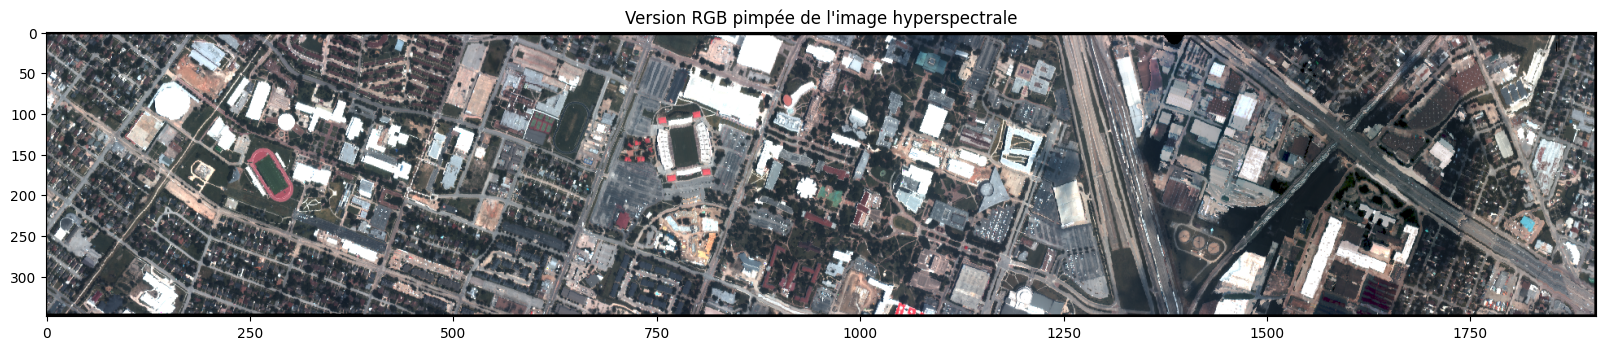

In [93]:
plt.figure(figsize=(20,8))
plt.title("Version RGB pimpée de l'image hyperspectrale")
plt.imshow(hsi_rgb_pimped)
plt.show()

In [94]:
# Linéariser la matrice 3d
_2d = np.reshape(data_for_prediction,(h*w, bands+2))

In [95]:
# Test pour voir si on peut la reformer en 3d
np.unique(np.reshape(_2d, (h, w, bands + 2)) == data_for_prediction)

array([ True])

## Prediction on the whole matrix

In [96]:
%%time
prediction = classifier.predict(_2d)

CPU times: user 39.1 s, sys: 197 ms, total: 39.3 s
Wall time: 39.4 s


In [97]:
prediction_2d = np.reshape(prediction, (h, w))

In [98]:
assert np.unique(prediction_2d).tolist() == [*range(1, 16)]

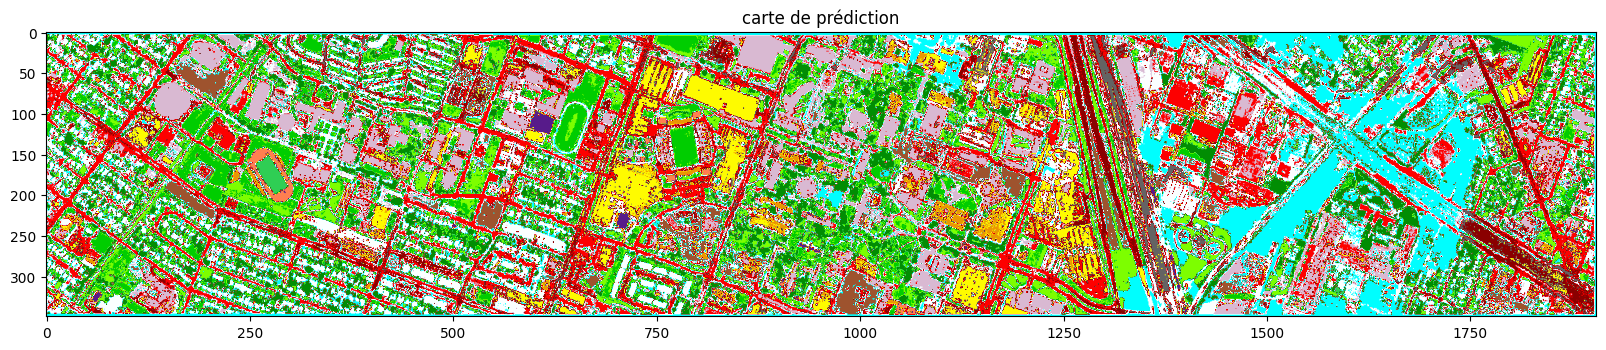

In [99]:
plt.figure(figsize=(20,5))
plt.title('carte de prédiction')
plt.imshow(prediction_2d, cmap=cmap)
plt.show()

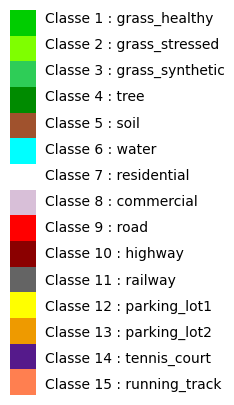

In [100]:
cls_rgb = []
for ii in groundtruth_info:
    cls_rgb.append(ii['class_color'])
cls_rgb = np.array(cls_rgb).reshape(15,-1,3)
plt.figure(figsize=(5,5))
plt.imshow(cls_rgb)
plt.axis('off')
for cls in range(15):
        plt.text(0.85,1.02*cls,'Classe %d : %s'%(cls+1,groundtruth_info[cls]['class_name']))
plt.show()

# Removing noise

Juste un essai en utilisant 10 ouvertures pour réduire le bruit

In [101]:
mask = skimage.morphology.square(2)
eroded = prediction_2d.copy()
for _ in range(10):
    eroded = skimage.morphology.opening(eroded, mask)

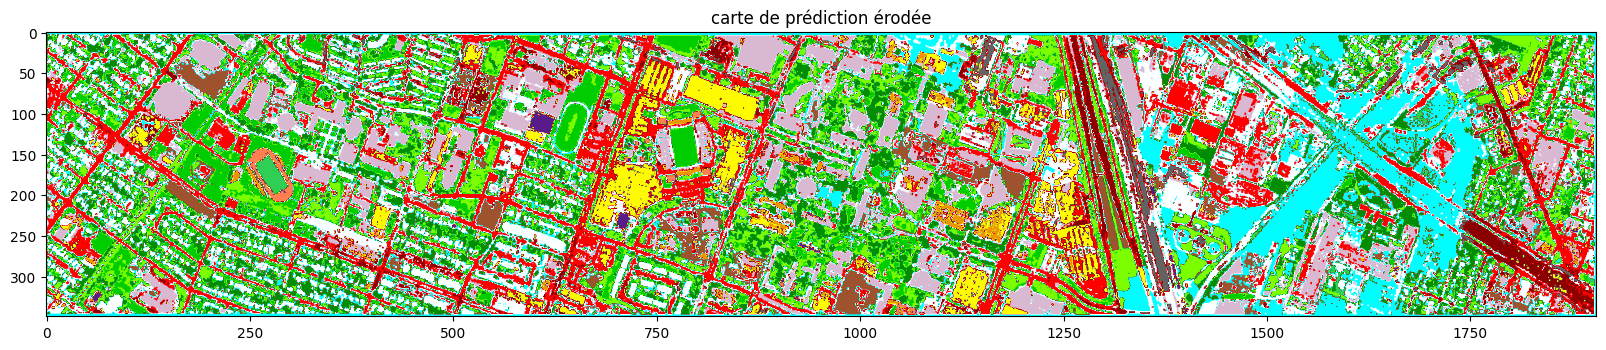

In [102]:
plt.figure(figsize=(20,5))
plt.title('carte de prédiction érodée')
plt.imshow(eroded, cmap=cmap)
plt.show()